In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Makes pandas tables easier to read in the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Paths are relative to the notebooks folder
# Path for the csv
DATA_PATH = Path("../data/processed/steam_games_analysis.csv")
# Path for the generated charts
CHART_PATH = Path("../outputs/charts")

# Makes sure the chart path exists
CHART_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df.head()


,app_id,name,release_date,price,developers,publishers,genres,positive_reviews,negative_reviews,review_pct,total_reviews,estimated_owners,average_playtime_forever,peak_ccu,recommendations,release_year,price_type,estimated_owners_midpoint,success_label,price_bucket
0,730,Counter-Strike 2,2012-08-21,0.00,['Valve'],['Valve'],"['Action', 'Free To Play']",7480813,1135108,0.86,"8,632,939.00",100000000 - 200000000,33189,1212356,4401572,2012,Free,"150,000,000.00",Successful,Free
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,['PUBG Corporation'],"['KRAFTON, Inc.']","['Action', 'Adventure', 'Massively Multiplayer...",1487960,1024436,0.59,"2,513,842.00",50000000 - 100000000,0,616738,1732007,2017,Free,"75,000,000.00",Low / Unknown,Free
2,570,Dota 2,2013-07-09,0.00,['Valve'],['Valve'],"['Action', 'Strategy', 'Free To Play']",1998462,451338,0.81,"2,452,595.00",200000000 - 500000000,43031,555977,14337,2013,Free,"350,000,000.00",Successful,Free
3,271590,Grand Theft Auto V Legacy,2015-04-13,0.00,['Rockstar North'],['Rockstar Games'],"['Action', 'Adventure']",1719950,250012,0.87,"1,803,832.00",50000000 - 100000000,19323,117698,1803063,2015,Free,"75,000,000.00",Successful,Free
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,3.99,['Ubisoft Montreal'],['Ubisoft'],['Action'],1152763,218446,0.84,"1,168,020.00",20000000 - 50000000,14204,89916,1165929,2015,Paid,"35,000,000.00",Successful,$0-$5


In [61]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   app_id                     89618 non-null  int64  
 1   name                       89618 non-null  str    
 2   release_date               89618 non-null  str    
 3   price                      89618 non-null  float64
 4   developers                 89618 non-null  str    
 5   publishers                 89618 non-null  str    
 6   genres                     89618 non-null  str    
 7   positive_reviews           89618 non-null  int64  
 8   negative_reviews           89618 non-null  int64  
 9   review_pct                 53199 non-null  float64
 10  total_reviews              53199 non-null  float64
 11  estimated_owners           89618 non-null  str    
 12  average_playtime_forever   89618 non-null  int64  
 13  peak_ccu                   89618 non-null  int64  
 14  r

app_id                           0
name                             0
release_date                     0
price                            0
developers                       0
publishers                       0
genres                           0
positive_reviews                 0
negative_reviews                 0
review_pct                   36419
total_reviews                36419
estimated_owners                 0
average_playtime_forever         0
peak_ccu                         0
recommendations                  0
release_year                     0
price_type                       0
estimated_owners_midpoint        0
success_label                    0
price_bucket                     0
dtype: int64

In [62]:
# A game can have more than one genre.
# Since the genres are stored together in one column, I split them apart first.
genre_df = df.copy()

genre_df["genres"] = genre_df["genres"].astype(str).str.split(",")
genre_df = genre_df.explode("genres")
genre_df["genres"] = genre_df["genres"].str.strip()

# This removes blank or weird genre values if any show up
genre_df = genre_df[genre_df["genres"] != ""]
genre_df = genre_df[genre_df["genres"] != "nan"]

genre_df.head()

,app_id,name,release_date,price,developers,publishers,genres,positive_reviews,negative_reviews,review_pct,total_reviews,estimated_owners,average_playtime_forever,peak_ccu,recommendations,release_year,price_type,estimated_owners_midpoint,success_label,price_bucket
0,730,Counter-Strike 2,2012-08-21,0.00,['Valve'],['Valve'],['Action',7480813,1135108,0.86,"8,632,939.00",100000000 - 200000000,33189,1212356,4401572,2012,Free,"150,000,000.00",Successful,Free
0,730,Counter-Strike 2,2012-08-21,0.00,['Valve'],['Valve'],'Free To Play'],7480813,1135108,0.86,"8,632,939.00",100000000 - 200000000,33189,1212356,4401572,2012,Free,"150,000,000.00",Successful,Free
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,['PUBG Corporation'],"['KRAFTON, Inc.']",['Action',1487960,1024436,0.59,"2,513,842.00",50000000 - 100000000,0,616738,1732007,2017,Free,"75,000,000.00",Low / Unknown,Free
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,['PUBG Corporation'],"['KRAFTON, Inc.']",'Adventure',1487960,1024436,0.59,"2,513,842.00",50000000 - 100000000,0,616738,1732007,2017,Free,"75,000,000.00",Low / Unknown,Free
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,['PUBG Corporation'],"['KRAFTON, Inc.']",'Massively Multiplayer',1487960,1024436,0.59,"2,513,842.00",50000000 - 100000000,0,616738,1732007,2017,Free,"75,000,000.00",Low / Unknown,Free


In [63]:
# Questions 1 - Which genres receive the highest review scores?

# I am grouping by genre so I can compare average review scores
# I also count the number of games so tiny genres do not dominate the results
genre_review = genre_df.groupby("genres").agg(
    game_count=("name", "count"),
    avg_review_pct=("review_pct", "mean")
)

genre_review = genre_review.reset_index()

# I only want genres with at least 100 games
# Otherwise unpopular genres could skew the results
genre_review = genre_review[genre_review["game_count"] >= 100]

# Sort from highest average review score to lowest
genre_review = genre_review.sort_values("avg_review_pct", ascending=False)

genre_review.head(10)

,genres,game_count,avg_review_pct
101,['Utilities'],208,0.90
63,['Animation & Modeling',277,0.90
62,['Adventure'],1667,0.81
12,'Casual'],2047,0.80
81,['Indie'],2473,0.80
28,'Indie'],25982,0.80
61,['Adventure',17108,0.79
88,['RPG'],883,0.78
39,'Racing'],1039,0.78
22,'Free To Play'],5039,0.78


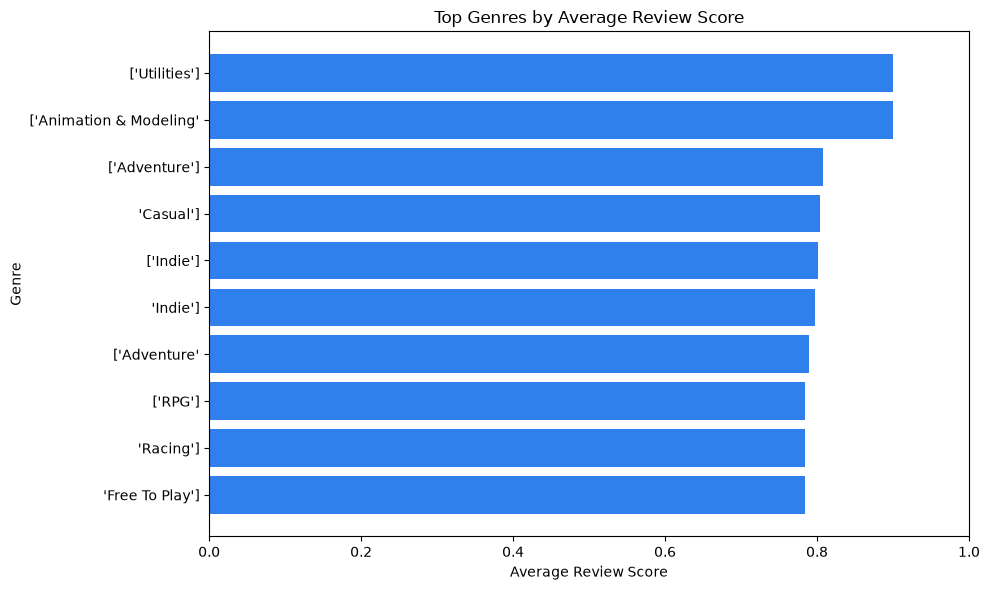

In [64]:
top_genres_review = genre_review.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres_review["genres"],
    top_genres_review["avg_review_pct"],
    color="#2F80ED"
)

plt.title("Top Genres by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Genre")
plt.xlim(0, 1)

# Highest value appears at the top instead of the bottom
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(CHART_PATH / "top_genres_by_review_score.png")
plt.show()

In [65]:
# Question 2 - Does price affect player satisfaction?

# Price buckets were created earlier in analyze_data.py. Tried to use common price ranges
# This lets me compare price ranges instead of looking at every exact price
price_review = df.groupby("price_bucket").agg(
    game_count=("name", "count"),
    avg_review_pct=("review_pct", "mean")
)

price_review = price_review.reset_index()

# This keeps the price buckets in a logical order on the chart. Tried to use common price ranges
price_order = ["Free", "$0-$5", "$5-$15", "$15-$30", "$30-$60", "$60+"]

price_review["price_bucket"] = pd.Categorical(
    price_review["price_bucket"],
    categories=price_order,
    ordered=True
)

price_review = price_review.sort_values("price_bucket")

price_review

,price_bucket,game_count,avg_review_pct
5,Free,14160,0.76
0,$0-$5,39456,0.76
3,$5-$15,26709,0.78
1,$15-$30,7606,0.78
2,$30-$60,1379,0.78
4,$60+,308,0.72


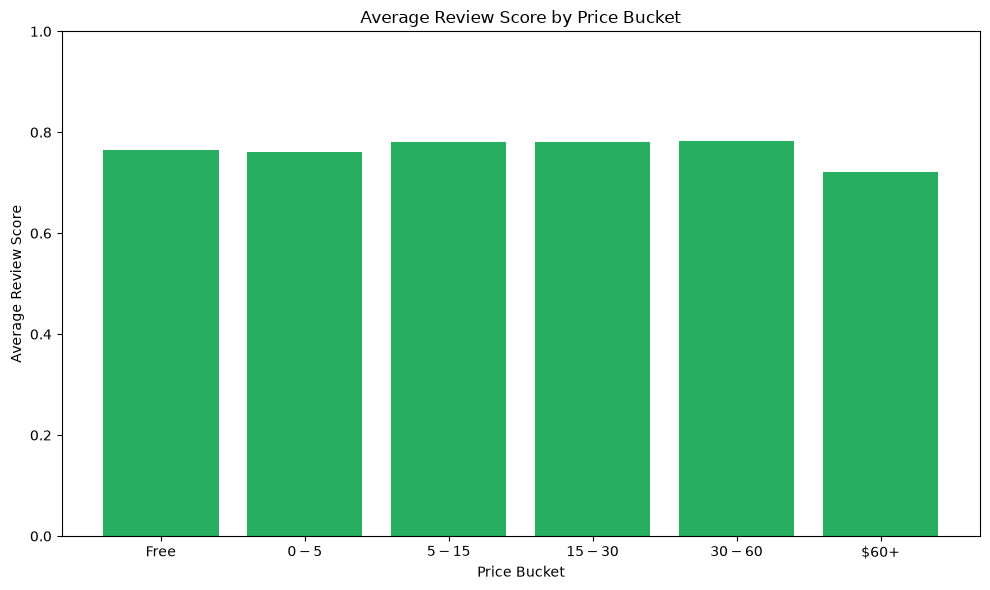

In [66]:
plt.figure(figsize=(10, 6))

plt.bar(
    price_review["price_bucket"],
    price_review["avg_review_pct"],
    color="#27AE60"
)

plt.title("Average Review Score by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Average Review Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(CHART_PATH / "review_score_by_price_bucket.png")
plt.show()

In [67]:
# Question 3 - What genres have the highest player engagement?

# For engagement, I am starting with average playtime
# Playtime is useful because it shows whether players actually spend time in the game
genre_engagement = genre_df.groupby("genres").agg(
    game_count=("name", "count"),
    avg_playtime=("average_playtime_forever", "mean"),
    avg_peak_ccu=("peak_ccu", "mean")
)

genre_engagement = genre_engagement.reset_index()

# Same idea as before: avoid ranking genres with only a tiny number of games
genre_engagement = genre_engagement[genre_engagement["game_count"] >= 100]

# Sort by average playtime first
genre_engagement = genre_engagement.sort_values(
    "avg_playtime",
    ascending=False
)

genre_engagement.head(10)

,genres,game_count,avg_playtime,avg_peak_ccu
25,'Gore',231,"2,322.34",0.25
3,'Action',314,"1,713.26",0.31
104,['Violent',362,"1,486.93",0.44
60,['Action'],2275,570.23,193.51
82,['Massively Multiplayer',156,551.92,374.88
42,'Simulation'],8258,375.85,43.03
43,'Software Training',134,370.20,73.37
51,'Utilities'],263,348.99,596.32
92,['Simulation',951,287.99,396.47
29,'Massively Multiplayer',1670,265.98,810.14


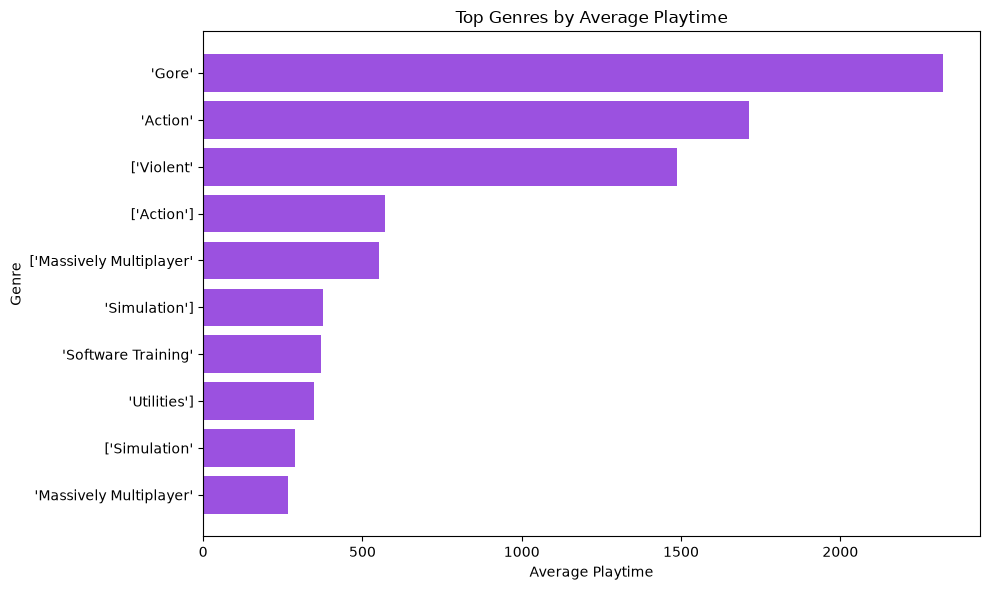

In [68]:
top_engagement = genre_engagement.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_engagement["genres"],
    top_engagement["avg_playtime"],
    color="#9B51E0"
)

plt.title("Top Genres by Average Playtime")
plt.xlabel("Average Playtime")
plt.ylabel("Genre")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(CHART_PATH / "top_genres_by_playtime.png")
plt.show()

In [69]:
# Question 4 - Do free games perform differently?

# This compares free and paid games side by side.
# I am looking at review score, owners, and peak players.
free_paid = df.groupby("price_type").agg(
    game_count=("name", "count"),
    avg_review_pct=("review_pct", "mean"),
    avg_owners=("estimated_owners_midpoint", "mean"),
    avg_peak_ccu=("peak_ccu", "mean")
)

free_paid = free_paid.reset_index()

free_paid

,price_type,game_count,avg_review_pct,avg_owners,avg_peak_ccu
0,Free,14160,0.76,"184,176.55",251.02
1,Paid,75458,0.77,"85,550.44",69.69


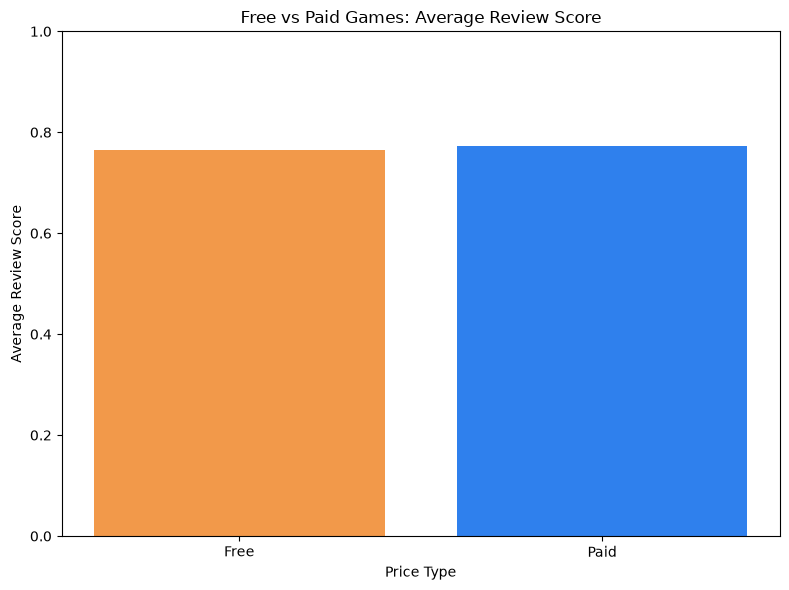

In [70]:
plt.figure(figsize=(8, 6))

plt.bar(
    free_paid["price_type"],
    free_paid["avg_review_pct"],
    color=["#F2994A", "#2F80ED"]
)

plt.title("Free vs Paid Games: Average Review Score")
plt.xlabel("Price Type")
plt.ylabel("Average Review Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(CHART_PATH / "free_vs_paid_review_score.png")
plt.show()

In [71]:
# Question 5 - What do most of the successful games have in common?

# I already created success_label in analyze_data.py
# Here I am looking only at the strongest group
top_performers = df[df["success_label"] == "Top Performer"]

# These are the columns that help explain what these games have in common
top_performers_view = top_performers[
    [
        "name",
        "price",
        "price_bucket",
        "genres",
        "review_pct",
        "total_reviews",
        "estimated_owners_midpoint",
        "average_playtime_forever",
        "peak_ccu"
    ]
]

top_performers_view = top_performers_view.sort_values(
    "total_reviews",
    ascending=False
)

top_performers_view.head(20)

,name,price,price_bucket,genres,review_pct,total_reviews,estimated_owners_midpoint,average_playtime_forever,peak_ccu
6,Terraria,9.99,$5-$15,"['Action', 'Adventure', 'Indie', 'RPG']",0.97,"1,102,434.00","35,000,000.00",0,30516
8,Garry's Mod,5.99,$5-$15,"['Casual', 'Indie', 'Simulation']",0.96,"985,010.00","35,000,000.00",10987,32384
10,Black Myth: Wukong,59.99,$30-$60,"['Action', 'Adventure', 'RPG']",0.96,"825,621.00","75,000,000.00",0,35990
11,The Witcher 3: Wild Hunt,39.99,$30-$60,['RPG'],0.96,"751,939.00","15,000,000.00",4411,15129
12,ELDEN RING,59.99,$30-$60,"['Action', 'RPG']",0.92,"749,606.00","35,000,000.00",11768,46121
13,Stardew Valley,14.99,$5-$15,"['Indie', 'RPG', 'Simulation']",0.98,"733,626.00","35,000,000.00",4871,67309
16,Baldur's Gate 3,59.99,$30-$60,"['Adventure', 'RPG', 'Strategy']",0.96,"648,637.00","35,000,000.00",9387,48021
17,Euro Truck Simulator 2,19.99,$15-$30,"['Indie', 'Simulation']",0.97,"641,347.00","15,000,000.00",0,43539
18,Red Dead Redemption 2,59.99,$30-$60,"['Action', 'Adventure']",0.92,"640,849.00","15,000,000.00",0,39811
20,Phasmophobia,19.99,$15-$30,"['Action', 'Indie', 'Early Access']",0.96,"616,505.00","15,000,000.00",2316,20766


In [72]:
# This table shows how top performers are spread across price buckets
# It is useful because it gives a quick idea of whether top games are usually free,
# cheap, mid-priced, or expensive
success_price = df.groupby(["price_bucket", "success_label"]).size()
success_price = success_price.reset_index(name="game_count")

price_order = ["Free", "$0-$5", "$5-$15", "$15-$30", "$30-$60", "$60+"]

success_price["price_bucket"] = pd.Categorical(
    success_price["price_bucket"],
    categories=price_order,
    ordered=True
)

success_price = success_price.sort_values("price_bucket")

success_price.head(20)

,price_bucket,success_label,game_count
17,Free,Top Performer,80
15,Free,Low / Unknown,13385
16,Free,Successful,695
0,$0-$5,Low / Unknown,38799
2,$0-$5,Top Performer,62
1,$0-$5,Successful,595
9,$5-$15,Low / Unknown,25370
10,$5-$15,Successful,1138
11,$5-$15,Top Performer,201
4,$15-$30,Successful,1055


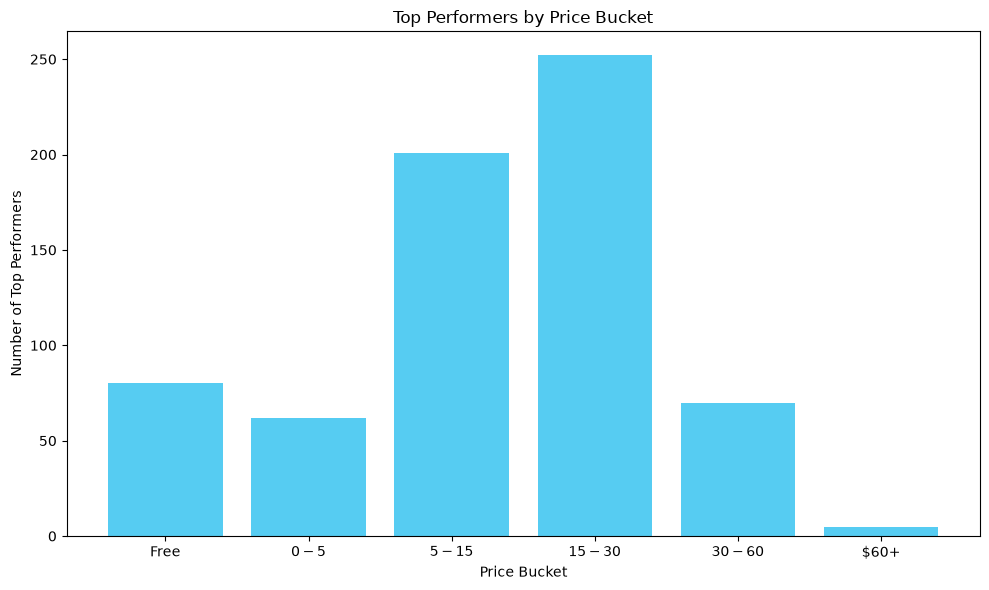

In [73]:
# For a simple chart, I am counting how many top performers fall in each price bucket.
top_by_price = success_price[
    success_price["success_label"] == "Top Performer"
]

plt.figure(figsize=(10, 6))

plt.bar(
    top_by_price["price_bucket"],
    top_by_price["game_count"],
    color="#56CCF2"
)

plt.title("Top Performers by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Number of Top Performers")

plt.tight_layout()
plt.savefig(CHART_PATH / "top_performers_by_price_bucket.png")
plt.show()

In [74]:
# Question 6 - Are there hidden gems? Games that recieve little attention relative to their reviews?
# Similar to my Sci-Fi book project

# For this project, I am defining hidden gems as games with:
# >= 90% positive review score
# between 500 and 5000 reviews
# Enoguh to have a real sample size but still unpopular

# The exact cutoff is somewhat random, but gives me a starting point.
# Have changed a few times

hidden_gems = df[
    (df["review_pct"] >= 0.90) &
    (df["total_reviews"] >= 500) &
    (df["total_reviews"] <= 5000)
]

# Sort by review score first, then total reviews.
# This puts the strongest hidden gem candidates near the top.
hidden_gems = hidden_gems.sort_values(
    ["review_pct", "total_reviews"],
    ascending=False
)

hidden_gems[
    [
        "name",
        "genres",
        "price",
        "review_pct",
        "total_reviews",
        "estimated_owners_midpoint"
    ]
].head(20)

,name,genres,price,review_pct,total_reviews,estimated_owners_midpoint
2410,"Please, Touch The Artwork 2","['Adventure', 'Casual', 'Indie']",0.00,0.99,"4,567.00",0.00
2594,Shiina Taki's Decameron,"['Casual', 'Indie', 'Free To Play']",0.00,0.99,"4,097.00",0.00
2714,买个可乐饼吧！ - Buy a Croquette!,"['Adventure', 'Casual', 'Indie', 'RPG', 'Strat...",0.00,0.99,"3,825.00",0.00
2860,A Castle Full of Cats,"['Adventure', 'Casual']",3.99,0.99,"3,555.00","75,000.00"
2917,Patrick's Parabox,"['Casual', 'Indie', 'Strategy']",19.99,0.99,"3,455.00","150,000.00"
3935,Aventura Copilului Albastru și Urât,"['Adventure', 'Casual', 'Indie']",1.99,0.99,"2,159.00","75,000.00"
3946,Threefold Recital,"['Adventure', 'Indie']",14.99,0.99,"2,148.00","10,000.00"
4499,A Tower Full of Cats,"['Adventure', 'Casual']",5.99,0.99,"1,744.00","35,000.00"
4554,Dialtown: Phone Dating Sim,"['Casual', 'Indie']",7.99,0.99,"1,709.00","75,000.00"
4675,BLACK BOX LSS - The Shining Immortal,"['Indie', 'RPG', 'Free To Play']",0.00,0.99,"1,637.00",0.00


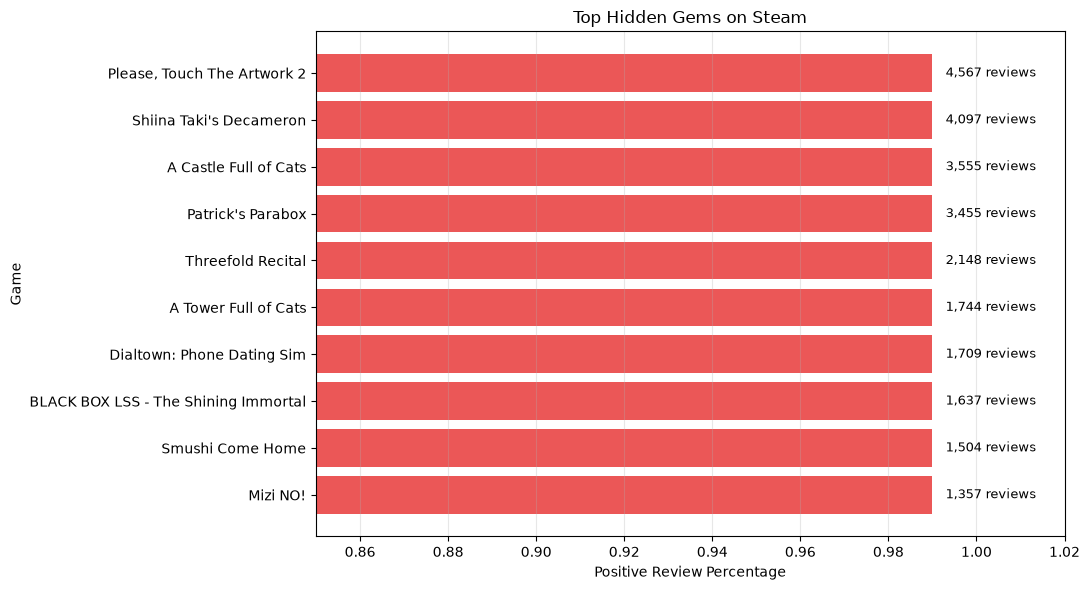

In [75]:
# Keep only games with English titles
hidden_gems = hidden_gems[
    hidden_gems["name"].str.isascii()
]

# Show the top 10 hidden gems
top_hidden_gems = hidden_gems.head(10)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_hidden_gems["name"],
    top_hidden_gems["review_pct"],
    color="#EB5757"
)

# Add the number of reviews to the end of each bar
for bar, reviews in zip(bars, top_hidden_gems["total_reviews"]):
    plt.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{int(reviews):,} reviews",
        va="center",
        fontsize=9
    )

plt.title("Top Hidden Gems on Steam")
plt.xlabel("Positive Review Percentage")
plt.ylabel("Game")
plt.xlim(0.85, 1.02)

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_PATH / "top_hidden_gems_by_review_score.png")
plt.show()